In [76]:
import sys
sys.path.append("../../src/")
from common_imports import *
from scipy.integrate import solve_ivp
from numpy import conj
from numpy import linalg as la
import kibble_zurek as kz
import time_evolved_z_correlators as zz
from time import time
#Load Pauli Matrices
s3,s1,s2 = array([[1,0],[0,-1]],dtype=complex),array([[0, 1],[1,0]],dtype=complex), array([[0,-1j],[1j,0]],dtype=complex)

In [158]:
#Time Dependent g
def g(t,tau,alpha=1):
    return (t/tau)**alpha
#TFIM functions
def a(q,g):
    return g+ cos(q)
def b(q,g):
    return sin(q)
def w(q,g):
    return sqrt(g*g+2*g*cos(q)+1)
def BdG(q,g):
    return -2*(a(q,g)*s3+b(q,g)*s2)
#Time Evolution
def BdG_Evolution(t,U,tau,q,alpha=1):
    return -1j*BdG(q,g(t,tau,alpha))@U
def BdG_stationary_evolve(t,U,tau,q,alpha=1):
    return -1j*BdG(q,g(tau,tau,alpha))@U
    

In [159]:
from joblib import Parallel, delayed

def evolve_mode(q, t0, tau, t_eval,alpha=1):
    V0 = la.eigh(BdG(q, g(t0, tau,alpha)))[1][:, 1]
    sol = solve_ivp(
        BdG_Evolution,
        [t0, t_eval[-1]],
        V0,
        args=(tau, q,alpha),
        t_eval=t_eval,
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
        max_step=0.05,
    )
    return sol.y[0], sol.y[1]

def landau_states(tau, L,alpha=1,ts=0):
    if ts==0:
        t0 = -tau
        tf = tau
    else:
        t0,tf = ts 
    n = np.arange(0, L // 2)
    k = (2 * n + 1) * pi / L
    t_eval = np.linspace(t0, tf, 100)

    results = Parallel(n_jobs=-1, prefer="processes")(
        delayed(evolve_mode)(q, t0, tau, t_eval,alpha) for q in k
    )

    us, vs = map(np.array, zip(*results))

    states = [[us[:, i], vs[:, i], k] for i in range(len(t_eval))]
    return states, t_eval


In [181]:
taus = np.logspace(-2,2,25)
data=[]
data2=[]
for tau in taus:
    dat = landau_states(tau,100,ts=(0,5*tau))
    fs = dat[0][-1]
    z = zz.P_n(2,fs)
    z2= kz.P_n(2,fs)
    data.append(z)
    data2.append(z2)
data=array(data)
data2 = array(data2)


/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/Numerical_Quench/../../src/time_evolved_z_correlators.py:49: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = kz.D(-Nd,state)


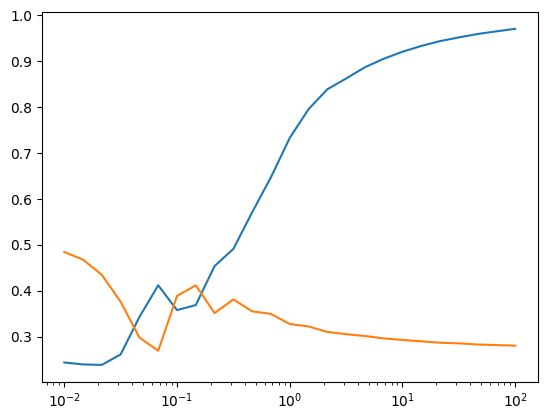

In [183]:
plot(taus,data)
plot(taus,array(data2))
#plot(taus,1/sqrt(taus),"--k")
xscale("log")

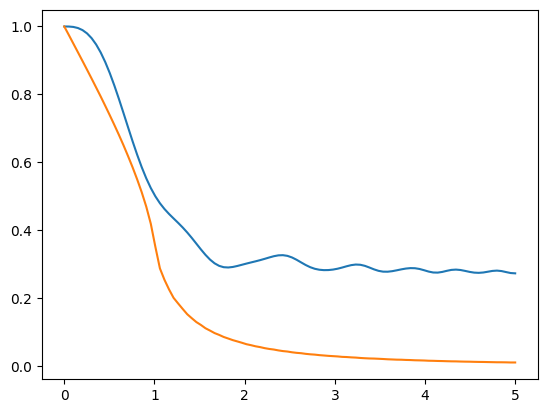

In [118]:
x1 = array([zz.sigma_general([0],s) for s in dat[0]])
x2 = array([zz.sigma_general([0],s) for s in dat2[0]])

plot(dat[1]/tau,1-x1)
plot(dat2[1]/tau2,1-x2)